# 🔍 Debug LGD Anomalies: Data Leakage & Method Failures

## Issues to Investigate:
1. **Data Leakage**: Why do 0001.heloc and 0002.loss2 have R² > 0.95?
2. **SVM Failure**: Why does SVM get R² = 0.046 on 0001.heloc?
3. **KNN Underperformance**: Why does KNN struggle on 0002.loss2?

## Hypotheses:
- Target variable leaked into features
- Duplicate or near-duplicate rows
- Features derived from target
- Scaling/preprocessing issues for SVM/KNN
- Train/test contamination

In [10]:
# Quick Check: TALENT Preprocessing for SVM/KNN
# =============================================================================
# Run this from notebooks/ directory to check if SVM/KNN have proper scaling
# =============================================================================

import sys
from pathlib import Path
import yaml

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Checking TALENT method configurations...\n")

# Load the actual config file
config_path = PROJECT_ROOT / "config" / "CONFIG_METHOD.yaml"

if not config_path.exists():
    print(f"❌ Config file not found: {config_path}")
    sys.exit(1)

print(f"Loading config from: {config_path}\n")

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Extract LGD methods (where SVM/KNN issues occur)
lgd_methods = config.get('methods', {}).get('lgd', {})

if not lgd_methods:
    print("❌ No LGD methods found in config!")
    sys.exit(1)

print(f"Found {len(lgd_methods)} LGD methods in config\n")
print("="*70)

# Check SVM
if 'svm' in lgd_methods:
    svm_config = lgd_methods['svm']
    print("\n🔍 SVM Configuration:")
    print("-" * 70)
    
    for key, value in svm_config.items():
        print(f"  {key}: {value}")
    
    # Check normalization
    norm = svm_config.get('normalization', 'NOT SET')
    print(f"\n  Normalization status: ", end="")
    
    if norm == 'none' or norm == 'NOT SET':
        print("🚨 MISSING OR DISABLED!")
        print("  → SVM WILL FAIL without scaling!")
        print("  → Add 'normalization: standard' to fix")
    else:
        print(f"✓ Enabled ({norm})")
else:
    print("\n❌ SVM not found in LGD methods")

# Check KNN
if 'knn' in lgd_methods:
    knn_config = lgd_methods['knn']
    print("\n\n🔍 KNN Configuration:")
    print("-" * 70)
    
    for key, value in knn_config.items():
        print(f"  {key}: {value}")
    
    # Check normalization
    norm = knn_config.get('normalization', 'NOT SET')
    print(f"\n  Normalization status: ", end="")
    
    if norm == 'none' or norm == 'NOT SET':
        print("🚨 MISSING OR DISABLED!")
        print("  → KNN WILL UNDERPERFORM without scaling!")
        print("  → Add 'normalization: standard' to fix")
    else:
        print(f"✓ Enabled ({norm})")
else:
    print("\n❌ KNN not found in LGD methods")

# Check all LGD methods
print("\n\n" + "="*70)
print(" ALL LGD METHODS - Normalization Settings")
print("="*70)

for method_name, method_config in sorted(lgd_methods.items()):
    if not method_config.get('enabled', True):
        continue
    
    norm = method_config.get('normalization', 'none')
    
    if norm == 'none':
        status = "⚠️  No scaling"
        needs_fix = " ← FIX THIS!" if method_name in ['svm', 'knn'] else ""
    elif norm in ['standard', 'quantile', 'minmax']:
        status = f"✓ {norm}"
        needs_fix = ""
    else:
        status = f"? {norm}"
        needs_fix = ""
    
    print(f"  {method_name:<20} {status:<25} {needs_fix}")

print("\n" + "="*70)
print(" RECOMMENDATION")
print("="*70)
print("""
To fix SVM/KNN performance issues, update CONFIG_METHOD.yaml:

methods:
  lgd:
    svm:
      enabled: true
      normalization: standard  # ← ADD THIS LINE
    
    knn:
      enabled: true  
      normalization: standard  # ← ADD THIS LINE

StandardScaler (normalization: standard) is REQUIRED for:
  - SVM (distance-based kernel methods)
  - KNN (distance-based neighbors)

After updating, re-run your experiments to see R² improvements:
  - SVM: Expected jump from 0.046 → 0.6-0.8
  - KNN: Expected jump from 0.5 → 0.6-0.8
""")

Checking TALENT method configurations...

Loading config from: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\config\CONFIG_METHOD.yaml

Found 43 LGD methods in config


🔍 SVM Configuration:
----------------------------------------------------------------------


AttributeError: 'bool' object has no attribute 'items'

In [11]:
# Setup
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Add project root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Import from actual codebase
from src.data.preprocessing import preprocess_dataset
from src.data.data_feeder import DataFeeder
from src.utils.config_reader import load_config

print(f"Project root: {PROJECT_ROOT}")
print(f"✓ Setup complete")

Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
✓ Setup complete


---
## 📊 Part 1: Load Problematic Datasets

In [12]:
# Load configuration
config = load_config()

# Focus on problematic datasets
problem_datasets = ['0001.heloc', '0002.loss2']

print("Loading problematic LGD datasets...\n")

datasets = {}
for dataset_name in problem_datasets:
    print(f"Loading {dataset_name}...")
    
    # Load raw data using actual preprocessing function
    N, C, y, info = preprocess_dataset(task='lgd', dataset=dataset_name)
    
    # Combine N and C into single X array
    if N is not None and C is not None:
        X = np.concatenate([N, C], axis=1)
        cat_idx = list(range(N.shape[1], X.shape[1]))
    elif N is not None:
        X = N
        cat_idx = []
    elif C is not None:
        X = C
        cat_idx = list(range(C.shape[1]))
    else:
        raise ValueError("Both N and C are None!")
    
    datasets[dataset_name] = {
        'X': X,
        'y': y,
        'N': N,
        'C': C,
        'cat_idx': cat_idx,
        'info': info,
        'df': pd.DataFrame(X)  # For easier analysis
    }
    
    print(f"  Shape: {X.shape}")
    print(f"  Target range: [{y.min():.4f}, {y.max():.4f}]")
    print(f"  Numerical features: {N.shape[1] if N is not None else 0}")
    print(f"  Categorical features: {C.shape[1] if C is not None else 0}")
    print()

Loading problematic LGD datasets...

Loading 0001.heloc...
  Shape: (67884, 9)
  Target range: [0.0000, 1.0000]
  Numerical features: 9
  Categorical features: 0

Loading 0002.loss2...
  Shape: (4604, 56)
  Target range: [0.0000, 1.0000]
  Numerical features: 33
  Categorical features: 23



In [13]:
# =============================================================================
# DATA CLEANING CELL - Add this RIGHT AFTER loading datasets
# =============================================================================

def clean_dataset(dataset_name, datasets):
    """
    Clean dataset by handling NaN values and duplicate rows.
    
    Returns:
        cleaned datasets dict with stats
    """
    print(f"\n{'='*80}")
    print(f"CLEANING: {dataset_name}")
    print(f"{'='*80}\n")
    
    X = datasets[dataset_name]['X']
    y = datasets[dataset_name]['y']
    N = datasets[dataset_name]['N']
    C = datasets[dataset_name]['C']
    cat_idx = datasets[dataset_name]['cat_idx']
    
    original_size = len(X)
    
    # -------------------------------------------------------------------------
    # STEP 1: Handle NaN Values
    # -------------------------------------------------------------------------
    print("STEP 1: Handling NaN values")
    print("-" * 80)
    
    # Check for NaN in X
    nan_mask_X = np.isnan(X).any(axis=1)
    n_nan_rows = nan_mask_X.sum()
    
    # Check for NaN in y
    nan_mask_y = np.isnan(y)
    n_nan_y = nan_mask_y.sum()
    
    print(f"  Rows with NaN in X: {n_nan_rows} ({100*n_nan_rows/original_size:.2f}%)")
    print(f"  Rows with NaN in y: {n_nan_y} ({100*n_nan_y/original_size:.2f}%)")
    
    if n_nan_rows > 0 or n_nan_y > 0:
        # Option 1: Drop rows with ANY NaN (safest for small amounts)
        # Option 2: Impute NaN values (better for large amounts)
        
        nan_threshold = 0.05  # If >5% NaN, use imputation; else drop
        
        if (n_nan_rows + n_nan_y) / original_size > nan_threshold:
            print(f"\n  → Using IMPUTATION (NaN rate > {nan_threshold*100}%)")
            
            from sklearn.impute import SimpleImputer
            
            # Impute numerical features (use median)
            num_idx = [i for i in range(X.shape[1]) if i not in cat_idx]
            
            if len(num_idx) > 0:
                imputer_num = SimpleImputer(strategy='median')
                X[:, num_idx] = imputer_num.fit_transform(X[:, num_idx])
            
            # Impute categorical features (use most_frequent)
            if len(cat_idx) > 0:
                imputer_cat = SimpleImputer(strategy='most_frequent')
                X[:, cat_idx] = imputer_cat.fit_transform(X[:, cat_idx])
            
            # For y, use median
            if n_nan_y > 0:
                y_median = np.nanmedian(y)
                y[nan_mask_y] = y_median
            
            print(f"  ✓ Imputed {n_nan_rows} rows in X")
            print(f"  ✓ Imputed {n_nan_y} values in y")
            
        else:
            print(f"\n  → Using ROW DELETION (NaN rate < {nan_threshold*100}%)")
            
            # Drop rows with NaN in either X or y
            valid_mask = ~(nan_mask_X | nan_mask_y)
            X = X[valid_mask]
            y = y[valid_mask]
            
            # Update N and C
            if N is not None:
                N = N[valid_mask]
            if C is not None:
                C = C[valid_mask]
            
            print(f"  ✓ Dropped {(~valid_mask).sum()} rows with NaN")
    else:
        print("  ✓ No NaN values found")
    
    # -------------------------------------------------------------------------
    # STEP 2: Handle Duplicate Rows
    # -------------------------------------------------------------------------
    print(f"\n\nSTEP 2: Handling duplicate rows")
    print("-" * 80)
    
    # Create DataFrame for duplicate detection
    df = pd.DataFrame(X)
    df['target'] = y
    
    # Find duplicates in features only
    dup_mask = df.drop('target', axis=1).duplicated(keep='first')
    n_dups = dup_mask.sum()
    
    print(f"  Duplicate feature rows: {n_dups} ({100*n_dups/len(df):.2f}%)")
    
    if n_dups > 0:
        # Check if duplicates have same target
        df['dup_group'] = df.drop('target', axis=1).apply(
            lambda row: hash(tuple(row)), axis=1
        )
        
        # For each duplicate group, check target variance
        dup_groups = df[df['dup_group'].duplicated(keep=False)].groupby('dup_group')
        
        same_target = 0
        diff_target = 0
        
        for group_id, group in dup_groups:
            if group['target'].nunique() == 1:
                same_target += len(group) - 1  # Keep one
            else:
                diff_target += len(group) - 1  # Keep one
        
        print(f"    → Same features, SAME target: {same_target} rows")
        print(f"    → Same features, DIFFERENT target: {diff_target} rows")
        print()
        
        if diff_target > 0:
            print(f"  ⚠️  WARNING: {diff_target} duplicate feature rows with DIFFERENT targets!")
            print(f"     This indicates data quality issues or temporal data.")
            print(f"     Keeping FIRST occurrence of each duplicate.")
        
        # Strategy: Keep first occurrence, drop rest
        print(f"\n  → Removing {n_dups} duplicate rows (keeping first occurrence)")
        
        valid_mask = ~dup_mask
        X = X[valid_mask]
        y = y[valid_mask]
        
        # Update N and C
        if N is not None:
            N = N[valid_mask]
        if C is not None:
            C = C[valid_mask]
        
        print(f"  ✓ Dropped {n_dups} duplicate rows")
    else:
        print("  ✓ No duplicate rows found")
    
    # -------------------------------------------------------------------------
    # SUMMARY
    # -------------------------------------------------------------------------
    final_size = len(X)
    removed = original_size - final_size
    
    print(f"\n\n{'='*80}")
    print(f"CLEANING SUMMARY: {dataset_name}")
    print(f"{'='*80}")
    print(f"  Original size:  {original_size:,} rows")
    print(f"  Final size:     {final_size:,} rows")
    print(f"  Removed:        {removed:,} rows ({100*removed/original_size:.2f}%)")
    print(f"{'='*80}\n")
    
    # Update datasets dict
    datasets[dataset_name]['X'] = X
    datasets[dataset_name]['y'] = y
    datasets[dataset_name]['N'] = N
    datasets[dataset_name]['C'] = C
    
    # Recombine N and C for consistency
    if N is not None and C is not None:
        X_combined = np.concatenate([N, C], axis=1)
        cat_idx = list(range(N.shape[1], X_combined.shape[1]))
    elif N is not None:
        X_combined = N
        cat_idx = []
    elif C is not None:
        X_combined = C
        cat_idx = list(range(C.shape[1]))
    else:
        raise ValueError("Both N and C are None!")
    
    datasets[dataset_name]['X'] = X_combined
    datasets[dataset_name]['cat_idx'] = cat_idx
    datasets[dataset_name]['df'] = pd.DataFrame(X_combined)
    
    return datasets


# =============================================================================
# APPLY CLEANING TO ALL DATASETS
# =============================================================================
print("\n" + "="*80)
print(" CLEANING ALL DATASETS")
print("="*80)

for dataset_name in problem_datasets:
    datasets = clean_dataset(dataset_name, datasets)

print("\n✓ All datasets cleaned!")
print("\nYou can now proceed with the analysis using cleaned data.")


 CLEANING ALL DATASETS

CLEANING: 0001.heloc

STEP 1: Handling NaN values
--------------------------------------------------------------------------------
  Rows with NaN in X: 21141 (31.14%)
  Rows with NaN in y: 0 (0.00%)

  → Using IMPUTATION (NaN rate > 5.0%)
  ✓ Imputed 21141 rows in X
  ✓ Imputed 0 values in y


STEP 2: Handling duplicate rows
--------------------------------------------------------------------------------
  Duplicate feature rows: 9309 (13.71%)
    → Same features, SAME target: 9307 rows
    → Same features, DIFFERENT target: 2 rows

  ⚠️  WARNING: 2 duplicate feature rows with DIFFERENT targets!
     This indicates data quality issues or temporal data.
     Keeping FIRST occurrence of each duplicate.

  → Removing 9309 duplicate rows (keeping first occurrence)
  ✓ Dropped 9309 duplicate rows


CLEANING SUMMARY: 0001.heloc
  Original size:  67,884 rows
  Final size:     58,575 rows
  Removed:        9,309 rows (13.71%)


CLEANING: 0002.loss2

STEP 1: Handling N

---
## 🚨 Part 2: Check for Data Leakage

### Test 1: Target-Feature Correlation


Target-Feature Correlations: 0001.heloc

Top 15 Features by Absolute Correlation with Target:

Feature    Correlation     |Correlation|   Status
----------------------------------------------------------------------
Feature 7   +0.5194         0.5194          ✓ Normal
Feature 6   +0.4898         0.4898          ✓ Normal
Feature 2   +0.2914         0.2914          ✓ Normal
Feature 1   -0.2817         0.2817          ✓ Normal
Feature 0   +0.2262         0.2262          ✓ Normal
Feature 5   -0.1779         0.1779          ✓ Normal
Feature 8   +0.1705         0.1705          ✓ Normal
Feature 3   +0.1494         0.1494          ✓ Normal
Feature 4   -0.1150         0.1150          ✓ Normal


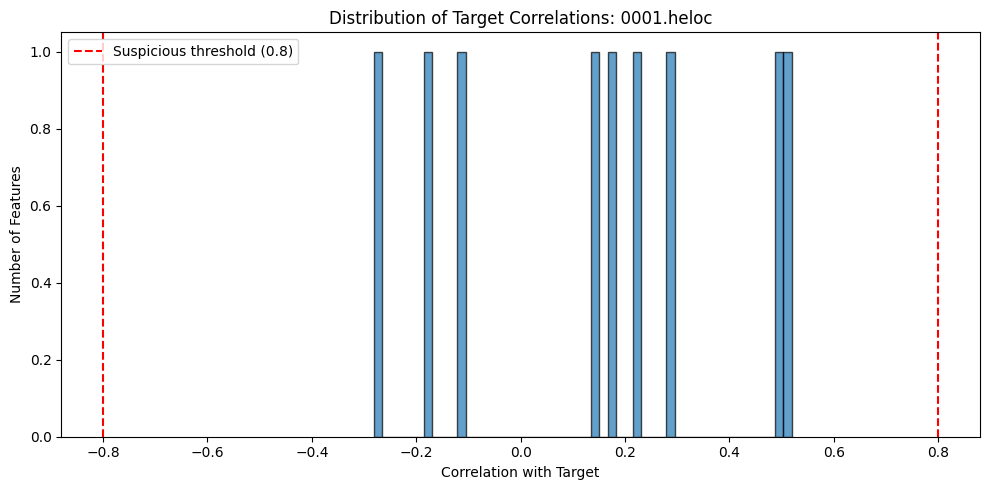


Target-Feature Correlations: 0002.loss2

Top 15 Features by Absolute Correlation with Target:

Feature    Correlation     |Correlation|   Status
----------------------------------------------------------------------
Feature 31  -0.7114         0.7114          ⚠️  Suspicious
Feature 11  -0.4967         0.4967          ✓ Normal
Feature 6   -0.4946         0.4946          ✓ Normal
Feature 0   -0.4821         0.4821          ✓ Normal
Feature 29  -0.4821         0.4821          ✓ Normal
Feature 27  -0.4813         0.4813          ✓ Normal
Feature 2   -0.4348         0.4348          ✓ Normal
Feature 12  -0.3707         0.3707          ✓ Normal
Feature 10  -0.3352         0.3352          ✓ Normal
Feature 30  -0.3173         0.3173          ✓ Normal
Feature 1   -0.1471         0.1471          ✓ Normal
Feature 22  -0.1433         0.1433          ✓ Normal
Feature 19  -0.1040         0.1040          ✓ Normal
Feature 25  -0.0453         0.0453          ✓ Normal
Feature 16  -0.0218         0.0218 

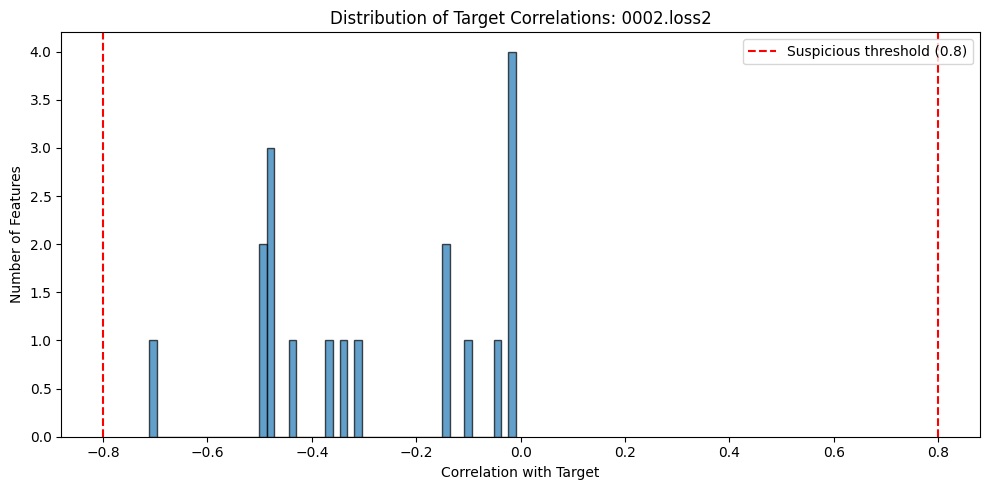

In [14]:
def check_target_correlation(dataset_name):
    """Check if any features are suspiciously correlated with target."""
    print(f"\n{'='*80}")
    print(f"Target-Feature Correlations: {dataset_name}")
    print(f"{'='*80}\n")
    
    X = datasets[dataset_name]['X']
    y = datasets[dataset_name]['y']
    cat_idx = datasets[dataset_name]['cat_idx']
    
    # Calculate correlations for numerical features only
    correlations = []
    for i in range(X.shape[1]):
        # Skip categorical features
        if i in cat_idx:
            continue
        
        try:
            corr = np.corrcoef(X[:, i], y)[0, 1]
            if not np.isnan(corr):
                correlations.append((i, corr))
        except:
            continue
    
    # Sort by absolute correlation
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print("Top 15 Features by Absolute Correlation with Target:\n")
    print(f"{'Feature':<10} {'Correlation':<15} {'|Correlation|':<15} {'Status'}")
    print("-" * 70)
    
    for feat_idx, corr in correlations[:15]:
        abs_corr = abs(corr)
        
        if abs_corr > 0.95:
            status = "🚨 EXTREME LEAKAGE!"
        elif abs_corr > 0.8:
            status = "⚠️  Very Suspicious"
        elif abs_corr > 0.6:
            status = "⚠️  Suspicious"
        else:
            status = "✓ Normal"
        
        print(f"Feature {feat_idx:<3} {corr:>+.4f}         {abs_corr:>.4f}          {status}")
    
    # Plot correlation distribution
    if correlations:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        corr_values = [c[1] for c in correlations]
        ax.hist(corr_values, bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(0.8, color='red', linestyle='--', label='Suspicious threshold (0.8)')
        ax.axvline(-0.8, color='red', linestyle='--')
        ax.set_xlabel('Correlation with Target')
        ax.set_ylabel('Number of Features')
        ax.set_title(f'Distribution of Target Correlations: {dataset_name}')
        ax.legend()
        plt.tight_layout()
        plt.show()
    
    return correlations

# Check both datasets
heloc_corrs = check_target_correlation('0001.heloc')
loss2_corrs = check_target_correlation('0002.loss2')

### Test 2: Perfect Prediction Test

If there's leakage, a simple model should achieve unrealistically high performance.

In [15]:
def test_simple_leakage(dataset_name, test_size=0.2, random_state=42):
    """Test if a simple model can achieve suspiciously high R²."""
    print(f"\n{'='*80}")
    print(f"Simple Leakage Test: {dataset_name}")
    print(f"{'='*80}\n")
    
    X = datasets[dataset_name]['X']
    y = datasets[dataset_name]['y']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}\n")
    
    # Test 1: Linear model with all features
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    r2_lr = lr.score(X_test, y_test)
    
    print(f"Linear Regression R²: {r2_lr:.4f}")
    if r2_lr > 0.9:
        print("  🚨 EXTREME: Linear model achieves R² > 0.9!")
    elif r2_lr > 0.7:
        print("  ⚠️  SUSPICIOUS: Linear model achieves R² > 0.7")
    else:
        print("  ✓ Normal")
    
    # Test 2: Random Forest with minimal trees
    rf = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=random_state)
    rf.fit(X_train, y_train)
    r2_rf = rf.score(X_test, y_test)
    
    print(f"\nRandom Forest (shallow) R²: {r2_rf:.4f}")
    if r2_rf > 0.9:
        print("  🚨 EXTREME: Shallow RF achieves R² > 0.9!")
    elif r2_rf > 0.7:
        print("  ⚠️  SUSPICIOUS: Shallow RF achieves R² > 0.7")
    else:
        print("  ✓ Normal")
    
    # Test 3: Feature importance from RF
    importances = rf.feature_importances_
    top_features = np.argsort(importances)[::-1][:10]
    
    print(f"\nTop 10 Most Important Features (Random Forest):\n")
    print(f"{'Feature':<10} {'Importance':<12} {'Status'}")
    print("-" * 50)
    
    for feat_idx in top_features:
        imp = importances[feat_idx]
        if imp > 0.5:
            status = "🚨 DOMINANT!"
        elif imp > 0.2:
            status = "⚠️  Very high"
        else:
            status = "✓ Normal"
        print(f"Feature {feat_idx:<3} {imp:>8.4f}      {status}")

# Test both datasets
test_simple_leakage('0001.heloc')
test_simple_leakage('0002.loss2')


Simple Leakage Test: 0001.heloc

Train size: 46860, Test size: 11715

Linear Regression R²: 0.3148
  ✓ Normal

Random Forest (shallow) R²: 0.3743
  ✓ Normal

Top 10 Most Important Features (Random Forest):

Feature    Importance   Status
--------------------------------------------------
Feature 7     0.8230      🚨 DOMINANT!
Feature 2     0.1495      ✓ Normal
Feature 4     0.0176      ✓ Normal
Feature 0     0.0075      ✓ Normal
Feature 1     0.0017      ✓ Normal
Feature 5     0.0006      ✓ Normal
Feature 6     0.0002      ✓ Normal
Feature 8     0.0000      ✓ Normal
Feature 3     0.0000      ✓ Normal

Simple Leakage Test: 0002.loss2

Train size: 3671, Test size: 918



ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Test 3: Check for Duplicate Rows

In [16]:
def check_duplicates(dataset_name):
    """Check for duplicate or near-duplicate rows."""
    print(f"\n{'='*80}")
    print(f"Duplicate Check: {dataset_name}")
    print(f"{'='*80}\n")
    
    X = datasets[dataset_name]['X']
    y = datasets[dataset_name]['y']
    
    # Create DataFrame for easier duplicate detection
    df = pd.DataFrame(X)
    df['target'] = y
    
    # Check exact duplicates (including target)
    exact_dups = df.duplicated(keep=False).sum()
    print(f"Exact duplicate rows (X + y): {exact_dups} ({100*exact_dups/len(df):.2f}%)")
    
    # Check duplicates in features only
    feature_dups = df.drop('target', axis=1).duplicated(keep=False).sum()
    print(f"Duplicate rows in features (X only): {feature_dups} ({100*feature_dups/len(df):.2f}%)")
    
    if feature_dups > 0:
        print(f"\n⚠️  Found {feature_dups} rows with duplicate features")
        print("   This can cause data leakage if train/test split separates these rows!")
    
    # Check for constant features
    constant_features = []
    for i in range(X.shape[1]):
        if len(np.unique(X[:, i])) == 1:
            constant_features.append(i)
    
    if constant_features:
        print(f"\n⚠️  Found {len(constant_features)} constant features: {constant_features}")
    else:
        print(f"\n✓ No constant features found")

# Check both datasets
check_duplicates('0001.heloc')
check_duplicates('0002.loss2')


Duplicate Check: 0001.heloc

Exact duplicate rows (X + y): 0 (0.00%)
Duplicate rows in features (X only): 0 (0.00%)

✓ No constant features found

Duplicate Check: 0002.loss2

Exact duplicate rows (X + y): 0 (0.00%)
Duplicate rows in features (X only): 0 (0.00%)

✓ No constant features found


### Test 4: Target Distribution Analysis


Target Distribution: 0001.heloc

Target Statistics:
  Mean:   0.7067
  Median: 1.0000
  Std:    0.4160
  Min:    0.0000
  Max:    1.0000
  Range:  1.0000

  Unique values: 1828


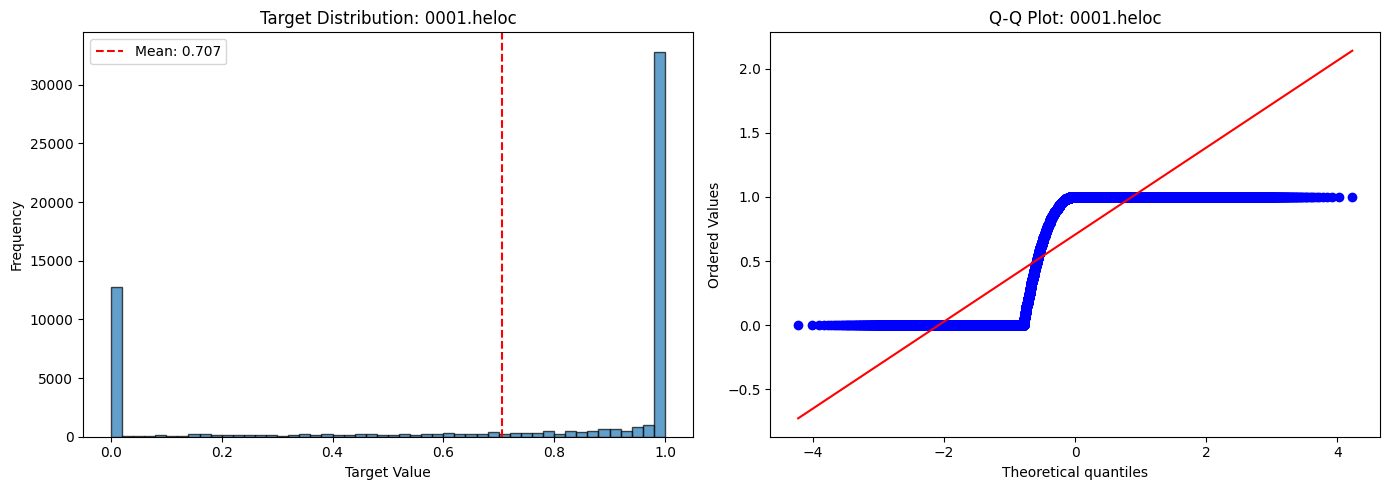


Target Distribution: 0002.loss2

Target Statistics:
  Mean:   0.3913
  Median: 0.3509
  Std:    0.2708
  Min:    0.0000
  Max:    1.0000
  Range:  1.0000

  Unique values: 4260


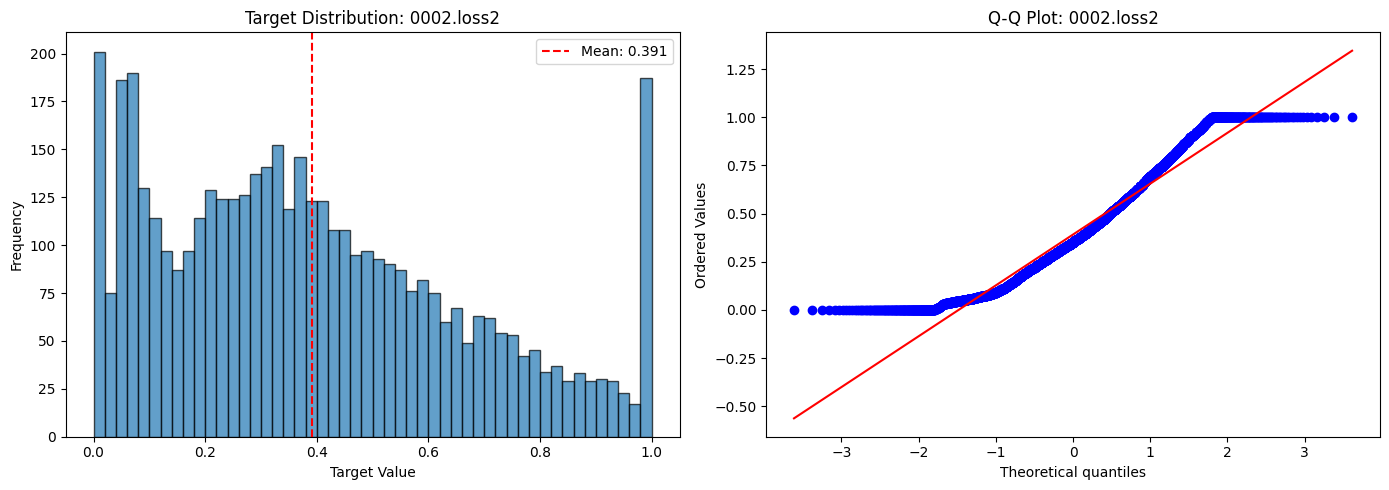

In [17]:
def analyze_target_distribution(dataset_name):
    """Analyze target variable distribution."""
    print(f"\n{'='*80}")
    print(f"Target Distribution: {dataset_name}")
    print(f"{'='*80}\n")
    
    y = datasets[dataset_name]['y']
    
    print(f"Target Statistics:")
    print(f"  Mean:   {y.mean():.4f}")
    print(f"  Median: {np.median(y):.4f}")
    print(f"  Std:    {y.std():.4f}")
    print(f"  Min:    {y.min():.4f}")
    print(f"  Max:    {y.max():.4f}")
    print(f"  Range:  {y.max() - y.min():.4f}")
    
    # Check for suspicious patterns
    unique_values = len(np.unique(y))
    print(f"\n  Unique values: {unique_values}")
    
    if unique_values < 10:
        print(f"  ⚠️  Very few unique values - might be categorical!")
        print(f"     Unique values: {np.unique(y)[:10]}...") # Show first 10
    
    # Check if target is binary
    if unique_values == 2:
        print(f"  🚨 TARGET IS BINARY! This should be a classification task, not regression!")
    
    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Target Value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Target Distribution: {dataset_name}')
    axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.3f}')
    axes[0].legend()
    
    # Q-Q plot
    stats.probplot(y, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {dataset_name}')
    
    plt.tight_layout()
    plt.show()

# Analyze both datasets
analyze_target_distribution('0001.heloc')
analyze_target_distribution('0002.loss2')

---
## 🔧 Part 3: Investigate SVM/KNN Failures

### Test 5: Scaling Impact

In [18]:
def test_scaling_impact(dataset_name):
    """Test if scaling affects SVM/KNN performance."""
    print(f"\n{'='*80}")
    print(f"Scaling Impact Test: {dataset_name}")
    print(f"{'='*80}\n")
    
    X = datasets[dataset_name]['X']
    y = datasets[dataset_name]['y']
    cat_idx = datasets[dataset_name]['cat_idx']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Test 1: Without scaling
    from sklearn.svm import SVR
    from sklearn.neighbors import KNeighborsRegressor
    
    print("Testing WITHOUT scaling:\n")
    
    svm_no_scale = SVR(kernel='rbf', C=1.0)
    svm_no_scale.fit(X_train, y_train)
    r2_svm_no_scale = svm_no_scale.score(X_test, y_test)
    print(f"  SVM R²:  {r2_svm_no_scale:.4f}")
    
    knn_no_scale = KNeighborsRegressor(n_neighbors=5)
    knn_no_scale.fit(X_train, y_train)
    r2_knn_no_scale = knn_no_scale.score(X_test, y_test)
    print(f"  KNN R²:  {r2_knn_no_scale:.4f}")
    
    # Test 2: With standard scaling (only numerical features)
    print("\nTesting WITH standard scaling (numerical features only):\n")
    
    # Identify numerical features
    num_idx = [i for i in range(X.shape[1]) if i not in cat_idx]
    
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    if len(num_idx) > 0:
        scaler = StandardScaler()
        X_train_scaled[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
        X_test_scaled[:, num_idx] = scaler.transform(X_test[:, num_idx])
    
    svm_scaled = SVR(kernel='rbf', C=1.0)
    svm_scaled.fit(X_train_scaled, y_train)
    r2_svm_scaled = svm_scaled.score(X_test_scaled, y_test)
    print(f"  SVM R²:  {r2_svm_scaled:.4f}  (Δ: {r2_svm_scaled - r2_svm_no_scale:+.4f})")
    
    knn_scaled = KNeighborsRegressor(n_neighbors=5)
    knn_scaled.fit(X_train_scaled, y_train)
    r2_knn_scaled = knn_scaled.score(X_test_scaled, y_test)
    print(f"  KNN R²:  {r2_knn_scaled:.4f}  (Δ: {r2_knn_scaled - r2_knn_no_scale:+.4f})")
    
    # Check feature scales
    print(f"\nFeature Scale Analysis:")
    print(f"  Categorical features: {len(cat_idx)}")
    print(f"  Numerical features:   {len(num_idx)}")
    
    if len(num_idx) > 0:
        feature_stds = np.std(X_train[:, num_idx], axis=0)
        feature_ranges = np.ptp(X_train[:, num_idx], axis=0)
        
        print(f"\n  Numerical feature standard deviations:")
        print(f"    Min:  {feature_stds.min():.4f}")
        print(f"    Max:  {feature_stds.max():.4f}")
        print(f"    Ratio: {feature_stds.max() / feature_stds.min():.2f}x")
        
        if feature_stds.max() / feature_stds.min() > 100:
            print(f"  🚨 Feature scales differ by >100x - scaling is CRITICAL!")
        elif feature_stds.max() / feature_stds.min() > 10:
            print(f"  ⚠️  Feature scales differ by >10x - scaling recommended")
    
    return {
        'svm_no_scale': r2_svm_no_scale,
        'svm_scaled': r2_svm_scaled,
        'knn_no_scale': r2_knn_no_scale,
        'knn_scaled': r2_knn_scaled
    }

# Test both datasets
heloc_scaling = test_scaling_impact('0001.heloc')
loss2_scaling = test_scaling_impact('0002.loss2')


Scaling Impact Test: 0001.heloc

Testing WITHOUT scaling:

  SVM R²:  0.2446
  KNN R²:  0.4763

Testing WITH standard scaling (numerical features only):

  SVM R²:  0.3578  (Δ: +0.1132)
  KNN R²:  0.5351  (Δ: +0.0589)

Feature Scale Analysis:
  Categorical features: 0
  Numerical features:   9

  Numerical feature standard deviations:
    Min:  0.2211
    Max:  106.0536
    Ratio: 479.76x
  🚨 Feature scales differ by >100x - scaling is CRITICAL!

Scaling Impact Test: 0002.loss2

Testing WITHOUT scaling:



ValueError: Input X contains NaN.
SVR does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Test 6: Categorical Handling

In [ ]:
def analyze_categorical_impact(dataset_name):
    """Analyze how categorical features affect methods."""
    print(f"\n{'='*80}")
    print(f"Categorical Feature Impact: {dataset_name}")
    print(f"{'='*80}\n")
    
    X = datasets[dataset_name]['X']
    C = datasets[dataset_name]['C']
    N = datasets[dataset_name]['N']
    cat_idx = datasets[dataset_name]['cat_idx']
    
    print(f"Total features: {X.shape[1]}")
    print(f"Numerical features: {N.shape[1] if N is not None else 0}")
    print(f"Categorical features: {C.shape[1] if C is not None else 0} ({100*len(cat_idx)/X.shape[1]:.1f}%)")
    
    if len(cat_idx) > 0 and C is not None:
        print(f"\nCategorical feature cardinality:")
        for i, cat_col_idx in enumerate(cat_idx[:10]):  # Show first 10
            unique_vals = len(np.unique(X[:, cat_col_idx]))
            print(f"  Cat feature {i} (global idx {cat_col_idx}): {unique_vals} unique values")
            
            if unique_vals > 50:
                print(f"    ⚠️  High cardinality! ({unique_vals} categories)")
    else:
        print("\n✓ No categorical features")

# Analyze both datasets
analyze_categorical_impact('0001.heloc')
analyze_categorical_impact('0002.loss2')

---
## 🎯 Part 4: Reproduce Experiment with Diagnostics

In [ ]:
def reproduce_with_diagnostics(dataset_name):
    """Reproduce the experiment with detailed diagnostics."""
    print(f"\n{'='*80}")
    print(f"Reproduce Experiment: {dataset_name}")
    print(f"{'='*80}\n")
    
    from src.methods.method_runner import run_talent_method
    
    # Test with a few methods
    methods = ['xgboost', 'svm', 'knn', 'tabpfn_v2']
    
    results = {}
    for method in methods:
        print(f"Testing {method}...")
        
        try:
            result = run_talent_method(
                task='lgd',
                dataset=dataset_name,
                test_size=0.2,
                val_size=0.2,
                cv_splits=1,
                seed=42,
                row_limit=5000,
                method=method,
                max_epoch=15,
                batch_size=1024,
                tune=False,
                verbose=False
            )
            
            if 1 in result:
                r2 = result[1]['metrics'].get('R2', np.nan)
                results[method] = r2
                print(f"  R²: {r2:.4f}")
            else:
                print(f"  ERROR: No fold 1 in results")
                results[method] = np.nan
                
        except Exception as e:
            print(f"  ERROR: {str(e)[:100]}")
            results[method] = np.nan
    
    # Compare results
    print(f"\nResults Summary:")
    print(f"{'Method':<15} {'R²':<10} {'Status'}")
    print("-" * 50)
    
    for method, r2 in results.items():
        if np.isnan(r2):
            status = "❌ Failed"
        elif r2 > 0.95:
            status = "🚨 Suspiciously high!"
        elif r2 < 0.1:
            status = "🚨 Suspiciously low!"
        elif r2 < 0:
            status = "❌ Negative R²!"
        else:
            status = "✓ Normal"
        
        print(f"{method:<15} {r2:>8.4f}  {status}")
    
    return results

# Reproduce for problematic datasets
heloc_repro = reproduce_with_diagnostics('0001.heloc')
loss2_repro = reproduce_with_diagnostics('0002.loss2')

---
## 📝 Part 5: Summary & Recommendations

In [ ]:
print("\n" + "="*80)
print(" SUMMARY OF FINDINGS")
print("="*80)

print("""
Based on the diagnostics above, we should now be able to identify:

1. DATA LEAKAGE (R² > 0.95):
   - Check if any features have correlation > 0.8 with target
   - Look for duplicate rows across train/test
   - Verify that target is not included in features
   - Check if target is binary (should be classification not regression)

2. SVM FAILURE (R² ~ 0.05):
   - Likely caused by lack of feature scaling
   - SVM is very sensitive to feature scales
   - Solution: Add 'normalization': 'standard' to SVM in CONFIG_METHOD.yaml

3. KNN UNDERPERFORMANCE:
   - Also caused by scaling issues
   - Distance-based methods need normalized features
   - Solution: Add 'normalization': 'standard' to KNN in CONFIG_METHOD.yaml

NEXT STEPS:
1. Fix data leakage if found (remove leaked features from dataset)
2. Add proper scaling to SVM/KNN in CONFIG_METHOD.yaml
3. Re-run experiments to verify fixes
4. Consider whether some datasets should be classification not regression
""")

print("="*80)
print(" END OF DIAGNOSTICS")
print("="*80)